## Sobolev neural network in 1D

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.trainer import SobolevTrainer, GeneralTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put

from black_scholes.tree import binomial_tree


In [2]:
exercise_type = 'american'

In [3]:
S0 = 1.0
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)
put_payoff = Put()

In [4]:
input_size = 2
hidden_sizes = [64, 128, 128, 64]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.0001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
loss_weights_sobolev = {
    'pde': 1.0,
    'J2': 0.15,
    'J3': 0.15,
    'J4': 0.15
}

Iteration 0, Loss: 0.2902103066444397
Iteration 100, Loss: 0.06491100043058395
Iteration 200, Loss: 0.009461107663810253
Iteration 300, Loss: 0.0049137212336063385
Iteration 400, Loss: 0.002670522080734372
Iteration 500, Loss: 0.002149916021153331
Iteration 600, Loss: 0.0015329744201153517
Iteration 700, Loss: 0.0009534573182463646
Iteration 800, Loss: 0.0011147769400849938
Iteration 900, Loss: 0.0006609129486605525
Iteration 1000, Loss: 0.0003942243638448417
Iteration 1100, Loss: 0.00029749784152954817
Iteration 1200, Loss: 0.0006098581361584365
Iteration 1300, Loss: 0.0005419551744125783
Iteration 1400, Loss: 0.0005625778576359153
Iteration 1500, Loss: 0.0004739575379062444
Iteration 1600, Loss: 0.00027485890313982964
Iteration 1700, Loss: 0.00040331645868718624
Early stopping at epoch 1754


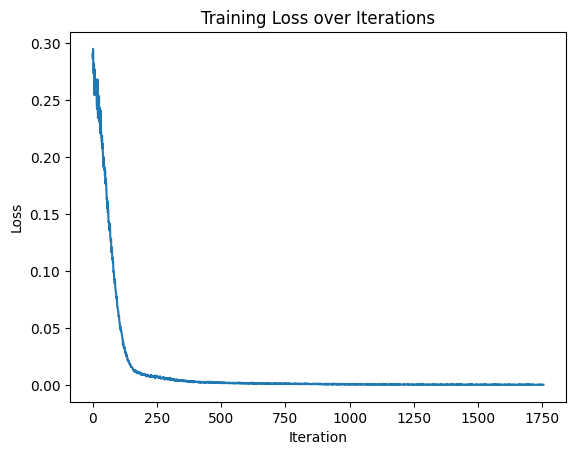

In [6]:
sobolev_trainer = SobolevTrainer(model_config, market_params, put_payoff, exercise_type=exercise_type, loss_weights=loss_weights_sobolev, seed=42)
sobolev_trainer.train(batch_size=1000, epochs=10000, tol=1e-7)
sobolev_trainer.plot_losses()

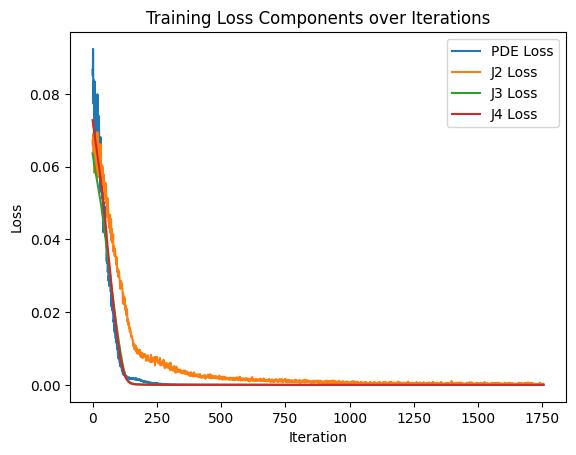

In [7]:
sobolev_trainer.plot_losses_detailed()

Iteration 0, Loss: 0.4871501922607422
Iteration 100, Loss: 0.11455345898866653
Iteration 200, Loss: 0.012925904244184494
Iteration 300, Loss: 0.003509039059281349
Iteration 400, Loss: 0.0014293892309069633
Iteration 500, Loss: 0.0006802001153118908
Iteration 600, Loss: 0.0004698175471276045
Iteration 700, Loss: 0.0003466675116214901
Iteration 800, Loss: 0.0002947404282167554
Iteration 900, Loss: 0.00025698720128275454
Iteration 1000, Loss: 0.00017189219943247736
Iteration 1100, Loss: 0.00017062343249563128
Iteration 1200, Loss: 0.00017316559387836605
Iteration 1300, Loss: 0.00013659248361364007
Iteration 1400, Loss: 0.00013301106810104102
Iteration 1500, Loss: 0.00011118341353721917
Iteration 1600, Loss: 0.00011826991976704448
Iteration 1700, Loss: 0.0001132909455918707
Iteration 1800, Loss: 9.500036685494706e-05
Iteration 1900, Loss: 9.339507960248739e-05
Iteration 2000, Loss: 9.704867989057675e-05
Iteration 2100, Loss: 8.797408372629434e-05
Iteration 2200, Loss: 8.703912317287177e-05

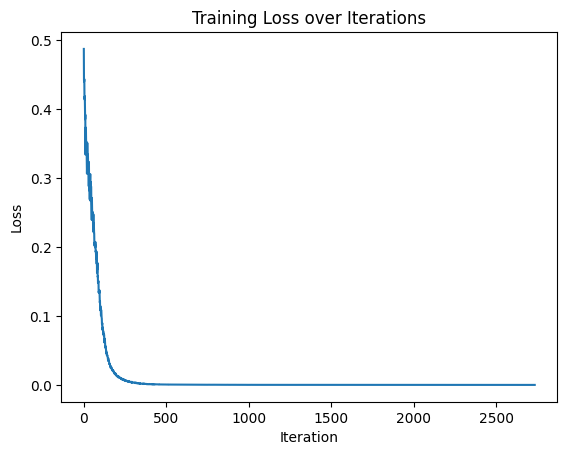

In [8]:
loss_weights = {
    'pde': 3.0,
    'exercise': 2.0,
    'boundary_Smax': 6,
    'boundary_Smin': 1/8
}

general_trainer = GeneralTrainer(model_config, market_params, put_payoff, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)
general_trainer.train(batch_size=1000, epochs=10000, tol=1e-7)
general_trainer.plot_losses()

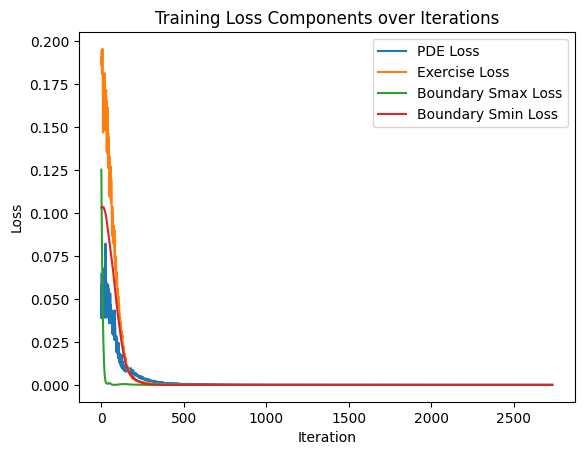

In [9]:
general_trainer.plot_losses_detailed()

In [10]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(1e-6, T, num_T)  # avoid exactly zero maturity

sb_prices = np.zeros((num_T, num_S))
nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        sb_prices[i, j] = sobolev_trainer.predict(t_val, s_val).item()
        nn_prices[i, j] = general_trainer.predict(t_val, s_val).item()
        bt_price, _, _ = binomial_tree(S=s_val, K=K, T=t_val, r=r, sigma=sigma, n=200)
        bt_prices[i, j] = float(bt_price)

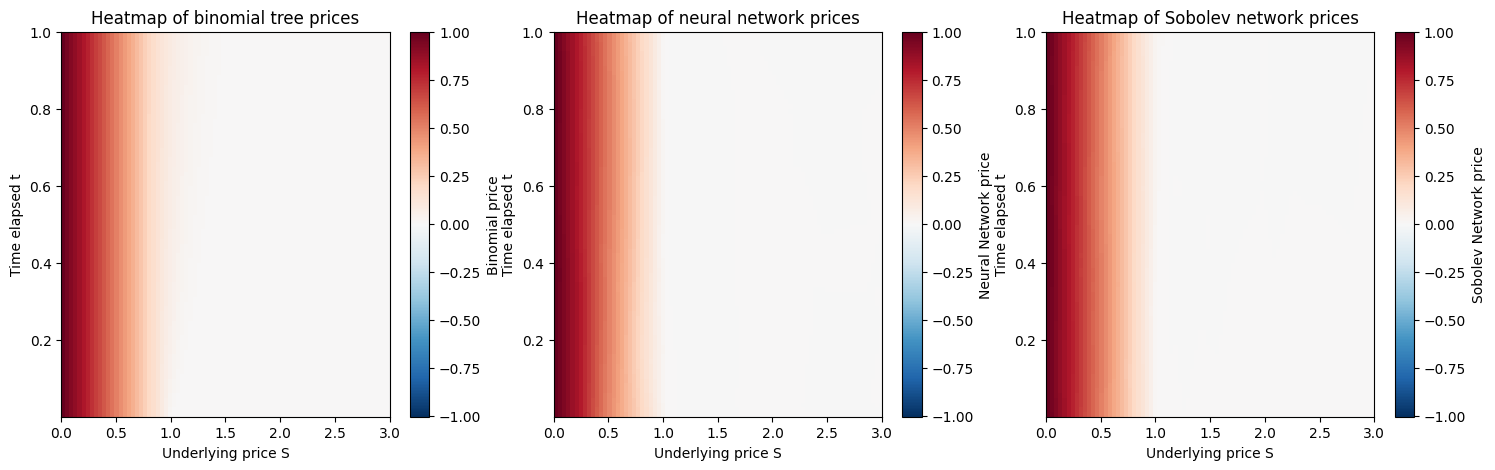

In [11]:
vmax = max(np.max(bt_prices), np.max(nn_prices), np.max(sb_prices))
vmin = -vmax

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
im = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of binomial tree prices')

plt.subplot(1, 3, 2)
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Neural Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of neural network prices')

plt.subplot(1, 3, 3)
im = plt.imshow(sb_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Sobolev Network price')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Heatmap of Sobolev network prices')

plt.show()

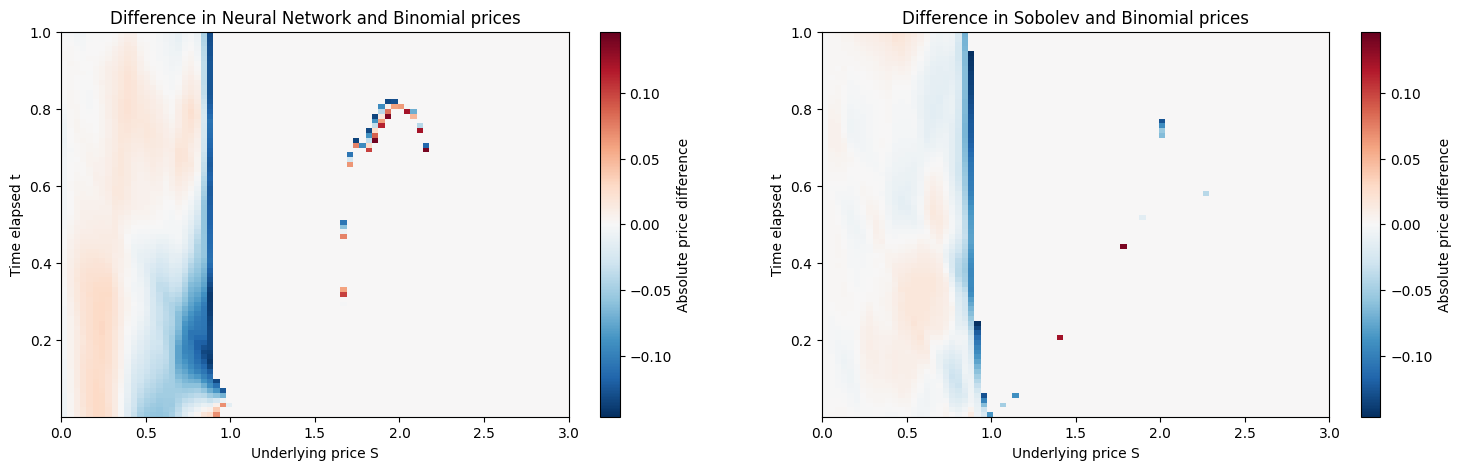

In [12]:
max_rel_error = 0.15

nn_bt_diff = (nn_prices - bt_prices) / np.maximum(bt_prices, 1e-8)
nn_bt_diff = np.where(np.abs(nn_bt_diff) > max_rel_error, 0, nn_bt_diff)

sb_bt_diff = (sb_prices - bt_prices) / np.maximum(bt_prices, 1e-8)
sb_bt_diff = np.where(np.abs(sb_bt_diff) > max_rel_error, 0, sb_bt_diff)

vmax = max(np.max(np.abs(nn_bt_diff)), np.max(np.abs(sb_bt_diff)))
vmin = -vmax

plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
im = plt.imshow(nn_bt_diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Neural Network and Binomial prices')

plt.subplot(1, 2, 2)
im = plt.imshow(sb_bt_diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='Absolute price difference')
plt.xlabel('Underlying price S')
plt.ylabel('Time elapsed t')
plt.title('Difference in Sobolev and Binomial prices')

plt.show()